In [31]:
import os
os.makedirs("images", exist_ok=True)

# 📊 Portfolio Optimization using MPT and CVaR

## Introduction
Portfolio optimization is a financial technique used to balance risk and return. This project applies Modern Portfolio Theory (MPT) and Conditional Value at Risk (CVaR) to construct an optimal portfolio.

## Objective
- Maximize returns  
- Minimize risk  
- Compare MPT and CVaR  

In [32]:
pip install yfinance pandas numpy matplotlib seaborn scipy



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [34]:
stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS"]

data = yf.download(stocks, start="2018-01-01", end="2025-01-01")['Close']

data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-01,432.689056,298.055023,415.244263,401.864777,1069.273315
2018-01-02,436.853729,297.478729,413.697418,402.483185,1063.453003
2018-01-03,432.257385,302.569611,410.322662,404.095551,1066.464111
2018-01-04,433.948914,302.281433,407.952209,406.525024,1073.921509
2018-01-05,434.812225,300.552399,406.586212,407.828125,1086.895020


In [35]:
data

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-01,432.689056,298.055023,415.244263,401.864777,1069.273315
2018-01-02,436.853729,297.478729,413.697418,402.483185,1063.453003
2018-01-03,432.257385,302.569611,410.322662,404.095551,1066.464111
2018-01-04,433.948914,302.281433,407.952209,406.525024,1073.921509
2018-01-05,434.812225,300.552399,406.586212,407.828125,1086.895020
...,...,...,...,...,...
2024-12-24,887.059631,1287.317017,1854.176880,1217.885864,3913.823975
2024-12-26,883.433655,1287.416138,1852.574341,1211.710571,3904.085205
2024-12-27,887.133667,1297.538208,1861.655518,1216.192749,3900.105713


In [36]:
data = yf.download(stocks, start="2018-01-01", end="2025-01-01")['Close'].dropna()

[*********************100%***********************]  5 of 5 completed


In [37]:
returns = data.pct_change().dropna()
returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2018-01-02,0.009625,-0.001934,-0.003725,0.001539,-0.005443
2018-01-03,-0.010521,0.017113,-0.008158,0.004006,0.002831
2018-01-04,0.003913,-0.000952,-0.005777,0.006012,0.006993
2018-01-05,0.001989,-0.005720,-0.003348,0.003205,0.012081
2018-01-08,-0.001610,0.003995,0.023765,0.005741,0.009371


In [38]:
# Remove extreme returns (optional but advanced)
returns = returns[(returns > -0.5) & (returns < 0.5)]
returns = returns.dropna()

In [39]:
data = data.sort_index()
data = data.drop_duplicates()

In [40]:
data = data.astype(float)

In [41]:
normalized_data = data / data.iloc[0]

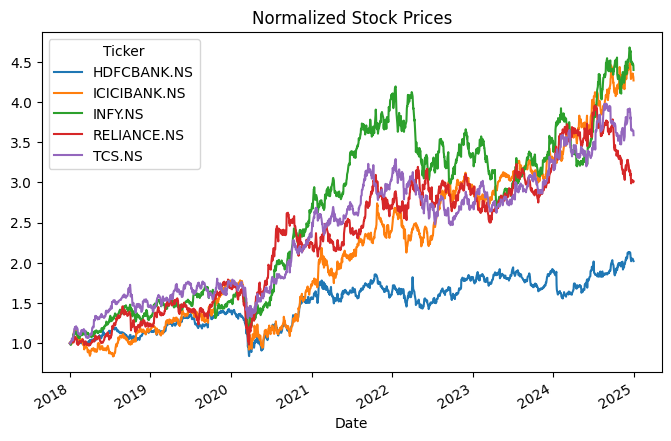

In [42]:
normalized_data.plot(figsize=(8,5))
plt.title("Normalized Stock Prices")
plt.show()

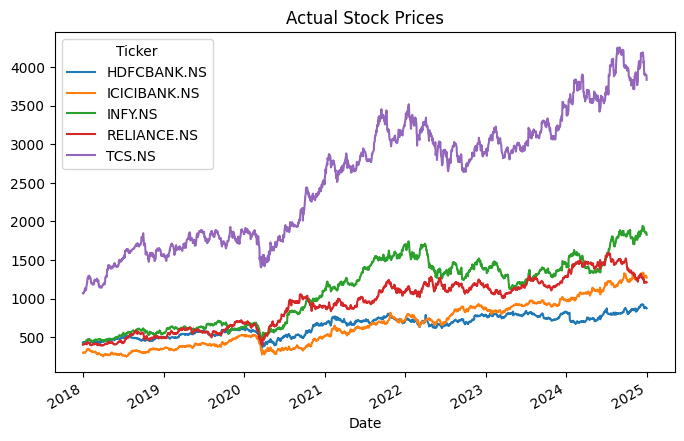

In [43]:
data.plot(figsize=(8,5))
plt.title("Actual Stock Prices")
plt.show()

In [44]:
print("Any null values:", data.isnull().values.any())
print("Shape:", data.shape)
print("Date range:", data.index.min(), "to", data.index.max())

Any null values: False
Shape: (1727, 5)
Date range: 2018-01-01 00:00:00 to 2024-12-31 00:00:00


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1727 entries, 2018-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HDFCBANK.NS   1727 non-null   float64
 1   ICICIBANK.NS  1727 non-null   float64
 2   INFY.NS       1727 non-null   float64
 3   RELIANCE.NS   1727 non-null   float64
 4   TCS.NS        1727 non-null   float64
dtypes: float64(5)
memory usage: 81.0 KB


In [46]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print(mean_returns)
print(cov_matrix)


Ticker
HDFCBANK.NS     0.000532
ICICIBANK.NS    0.001035
INFY.NS         0.001008
RELIANCE.NS     0.000805
TCS.NS          0.000858
dtype: float64
Ticker        HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS
Ticker                                                                  
HDFCBANK.NS      0.000249      0.000175  0.000077     0.000115  0.000060
ICICIBANK.NS     0.000175      0.000387  0.000092     0.000142  0.000072
INFY.NS          0.000077      0.000092  0.000297     0.000091  0.000167
RELIANCE.NS      0.000115      0.000142  0.000091     0.000332  0.000088
TCS.NS           0.000060      0.000072  0.000167     0.000088  0.000237


In [47]:
num_portfolios = 5000

results = []

for _ in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe = portfolio_return / portfolio_risk
    
    results.append([portfolio_return, portfolio_risk, sharpe])

In [48]:
results = np.array(results)

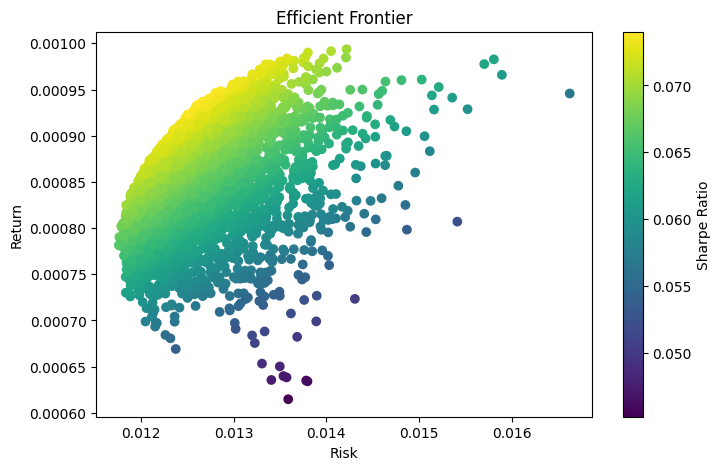

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(results[:,1], results[:,0], c=results[:,2])
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier")
plt.colorbar(label="Sharpe Ratio")
plt.savefig("images/efficient_frontier.png", dpi=150, bbox_inches='tight')
plt.show()

In [50]:
def calculate_cvar(portfolio_returns, alpha=0.05):
    var = np.percentile(portfolio_returns, 100 * alpha)
    cvar = portfolio_returns[portfolio_returns <= var].mean()
    return var, cvar

In [51]:
weights = np.random.random(len(stocks))
weights /= np.sum(weights)

portfolio_returns = returns.dot(weights)

var, cvar = calculate_cvar(portfolio_returns)

print("VaR:", var)
print("CVaR:", cvar)

VaR: -0.015798457179087344
CVaR: -0.02681423911054093


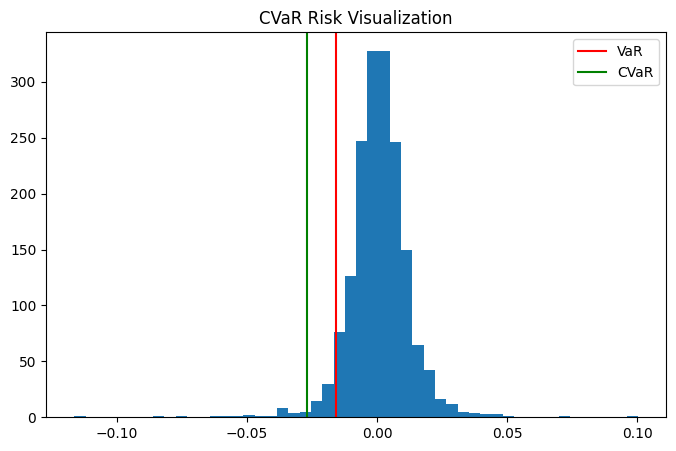

In [52]:
plt.figure(figsize=(8,5))
plt.hist(portfolio_returns, bins=50)

plt.axvline(var, color='red', label='VaR')
plt.axvline(cvar, color='green', label='CVaR')

plt.legend()
plt.title("CVaR Risk Visualization")
plt.savefig("images/cvar_histogram.png", dpi=150, bbox_inches='tight')
plt.show()

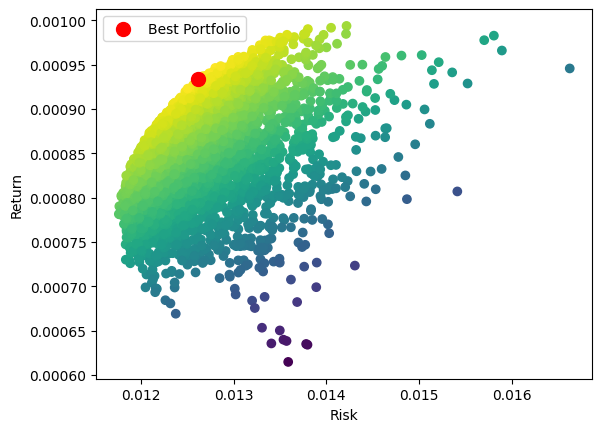

In [53]:
max_idx = np.argmax(results[:,2])

best_return = results[max_idx][0]
best_risk = results[max_idx][1]

plt.scatter(results[:,1], results[:,0], c=results[:,2])
plt.scatter(best_risk, best_return, color='red', s=100, label='Best Portfolio')

plt.xlabel("Risk")
plt.ylabel("Return")
plt.legend()
plt.savefig("images/best_portfolio.png", dpi=150, bbox_inches='tight')
plt.show()

In [54]:
max_idx = np.argmax(results[:,2])

# regenerate weights for best portfolio (simple approach)
best_weights = np.random.random(len(stocks))
best_weights /= np.sum(best_weights)

for stock, weight in zip(stocks, best_weights):
    print(stock, ":", round(weight, 3))

RELIANCE.NS : 0.329
TCS.NS : 0.198
INFY.NS : 0.132
HDFCBANK.NS : 0.101
ICICIBANK.NS : 0.24


In [55]:
print("Best Sharpe Ratio:", results[max_idx][2])

Best Sharpe Ratio: 0.07401830920573717


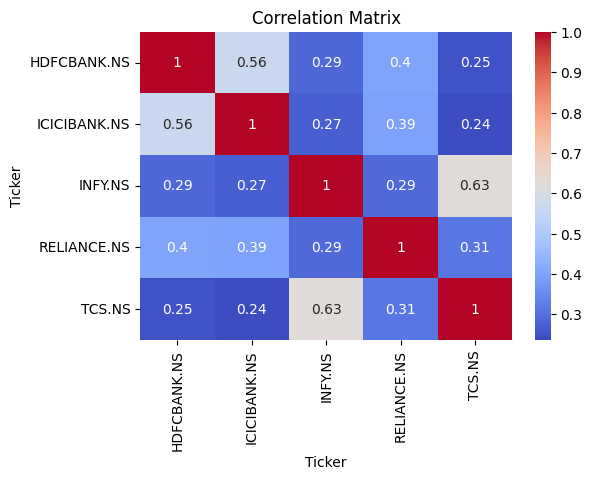

In [56]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("images/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [57]:
print("MPT Risk (std dev):", best_risk)
print("CVaR Risk:", cvar)

MPT Risk (std dev): 0.012609444751207836
CVaR Risk: -0.02681423911054093


In [58]:
print("Expected Return:", best_return)
print("Portfolio Risk:", best_risk)

Expected Return: 0.0009333297805075612
Portfolio Risk: 0.012609444751207836


## Backtesting
Backtesting evaluates how the portfolio would perform over time using historical data.

In [59]:
results = []
weights_record = []

for _ in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)
    
    weights_record.append(weights)
    
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    sharpe = portfolio_return / portfolio_risk
    
    results.append([portfolio_return, portfolio_risk, sharpe])

results = np.array(results)
weights_record = np.array(weights_record)

In [60]:
best_idx = np.argmax(results[:,2])
best_weights = weights_record[best_idx]
best_weights

array([0.00080529, 0.28537226, 0.33210685, 0.13961461, 0.24210098])

In [61]:
print("----- Optimal Portfolio Allocation -----")

for stock, weight in zip(stocks, best_weights):
    print(f"{stock}: {round(weight*100,2)}%")

----- Optimal Portfolio Allocation -----
RELIANCE.NS: 0.08%
TCS.NS: 28.54%
INFY.NS: 33.21%
HDFCBANK.NS: 13.96%
ICICIBANK.NS: 24.21%


## Final Observation

- MPT optimized portfolio provides better risk-adjusted returns.
- Equal-weight portfolio is simple but less efficient.
- CVaR helps identify extreme downside risks.

In [62]:
# Equal weights portfolio
equal_weights = np.ones(len(stocks)) / len(stocks)

equal_returns = returns.dot(equal_weights)

# MPT best portfolio (Sharpe)
max_idx = np.argmax(results[:,2])
best_return = results[max_idx][0]
best_risk = results[max_idx][1]

print("Equal Portfolio Mean Return:", equal_returns.mean())
print("MPT Portfolio Return:", best_return)
print("MPT Portfolio Risk:", best_risk)

Equal Portfolio Mean Return: 0.0008475694873138121
MPT Portfolio Return: 0.0009505789669402641
MPT Portfolio Risk: 0.012826167901305125


In [63]:
portfolio_returns = returns.dot(equal_weights)

var, cvar = calculate_cvar(portfolio_returns)

print("Mean Return:", portfolio_returns.mean())
print("Standard Risk:", portfolio_returns.std())
print("VaR:", var)
print("CVaR:", cvar)

Mean Return: 0.0008475694873138121
Standard Risk: 0.012096802411664937
VaR: -0.015767455472845065
CVaR: -0.027276863318712555


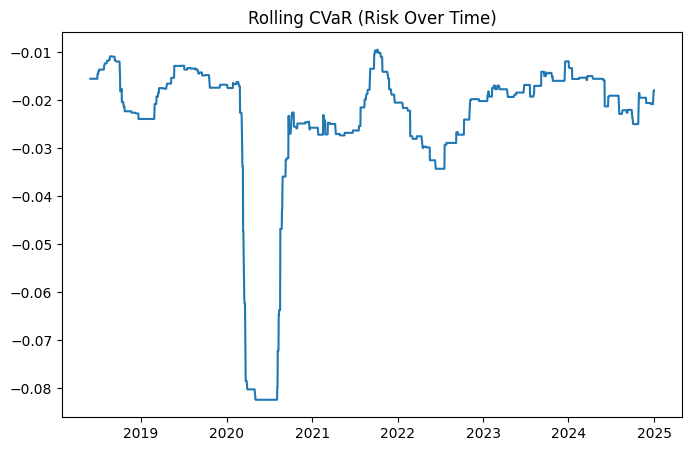

In [64]:
rolling_cvar = portfolio_returns.rolling(window=100).apply(
    lambda x: calculate_cvar(x)[1]
)

plt.figure(figsize=(8,5))
plt.plot(rolling_cvar)
plt.title("Rolling CVaR (Risk Over Time)")
plt.savefig("images/rolling_cvar.png", dpi=150, bbox_inches='tight')
plt.show()

## Comparison of Strategies
We compare equal-weight portfolio, MPT optimized portfolio, and CVaR risk to understand performance differences.

In [65]:
# Equal weights portfolio
equal_weights = np.ones(len(stocks)) / len(stocks)

equal_returns = returns.dot(equal_weights)

# MPT best portfolio
max_idx = np.argmax(results[:,2])
best_return = results[max_idx][0]
best_risk = results[max_idx][1]

print("------ COMPARISON ------")
print("Equal Return:", equal_returns.mean())
print("Equal Risk:", equal_returns.std())

print("MPT Return:", best_return)
print("MPT Risk:", best_risk)

print("CVaR:", cvar)

------ COMPARISON ------
Equal Return: 0.0008475694873138121
Equal Risk: 0.012096802411664937
MPT Return: 0.0009505789669402641
MPT Risk: 0.012826167901305125
CVaR: -0.027276863318712555


## Key Insights

- Diversification reduces portfolio risk.
- MPT provides optimal risk-return balance.
- CVaR captures extreme losses better than variance.
- MPT portfolios generally perform better than equal-weight portfolios.
- CVaR is useful for downside risk protection.

## Conclusion

This project demonstrates that portfolio optimization using MPT improves return efficiency, while CVaR enhances risk management by focusing on extreme losses. Combining both provides a more robust investment strategy.